# Visualisation des modèles

In [1]:
import numpy as np
#from scipy.optimize import linprog
#import pandas as pd
#import pulp
#import networkx as nx
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

import fonctions_communes as fct
import fonctions_complet as com
import fonctions_separe as sep

## 1. Chargement des données (fictives)

#### Chargement des données pour 1 pays du code jouet

In [2]:
df_demand, df_solar, df_wind, solar_capacity, wind_capacity = fct.charge_data()

Capacités requises: éolien = 297.6GW, solaire = 539.7GW


#### Transformation pour simuler N pays différents

In [3]:
N = 5 # Choix du nombre de pays

demand_N, solar_N, wind_N, solar_cap_N, wind_cap_N = fct.transfo_multipays(df_demand, df_solar, df_wind, solar_capacity, wind_capacity, N)

#### Chargement des capacité d'échange maximales

In [4]:
qmax7pays = fct.capa_max_echanges()
qmax = qmax7pays[:N,:N]
print("Matrice des capacités d'échanges max :")
print(qmax)

Matrice des capacités d'échanges max :
[[0.  0.9 0.4 1.7 0.2]
 [1.1 0.  0.  0.  0. ]
 [3.5 0.  0.  2.  0. ]
 [1.7 0.  2.8 0.  0. ]
 [1.8 0.  0.  2.4 0. ]]


## Complet (1 période)

In [5]:
result = com.optimize(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=30*180, #modifié en faisant 30*
    phs_power=5*9.3, #modifié en faisant 5*
    phs_eff=0.75,  
    ptg_capacity=125000,
    ptg_power_in=100*7.66, #modifié en faisant 100*
    ptg_power_out=2*32.93,  #modifié en faisant 2*
    ptg_eff=0.4
)

#### Interprétation graphique

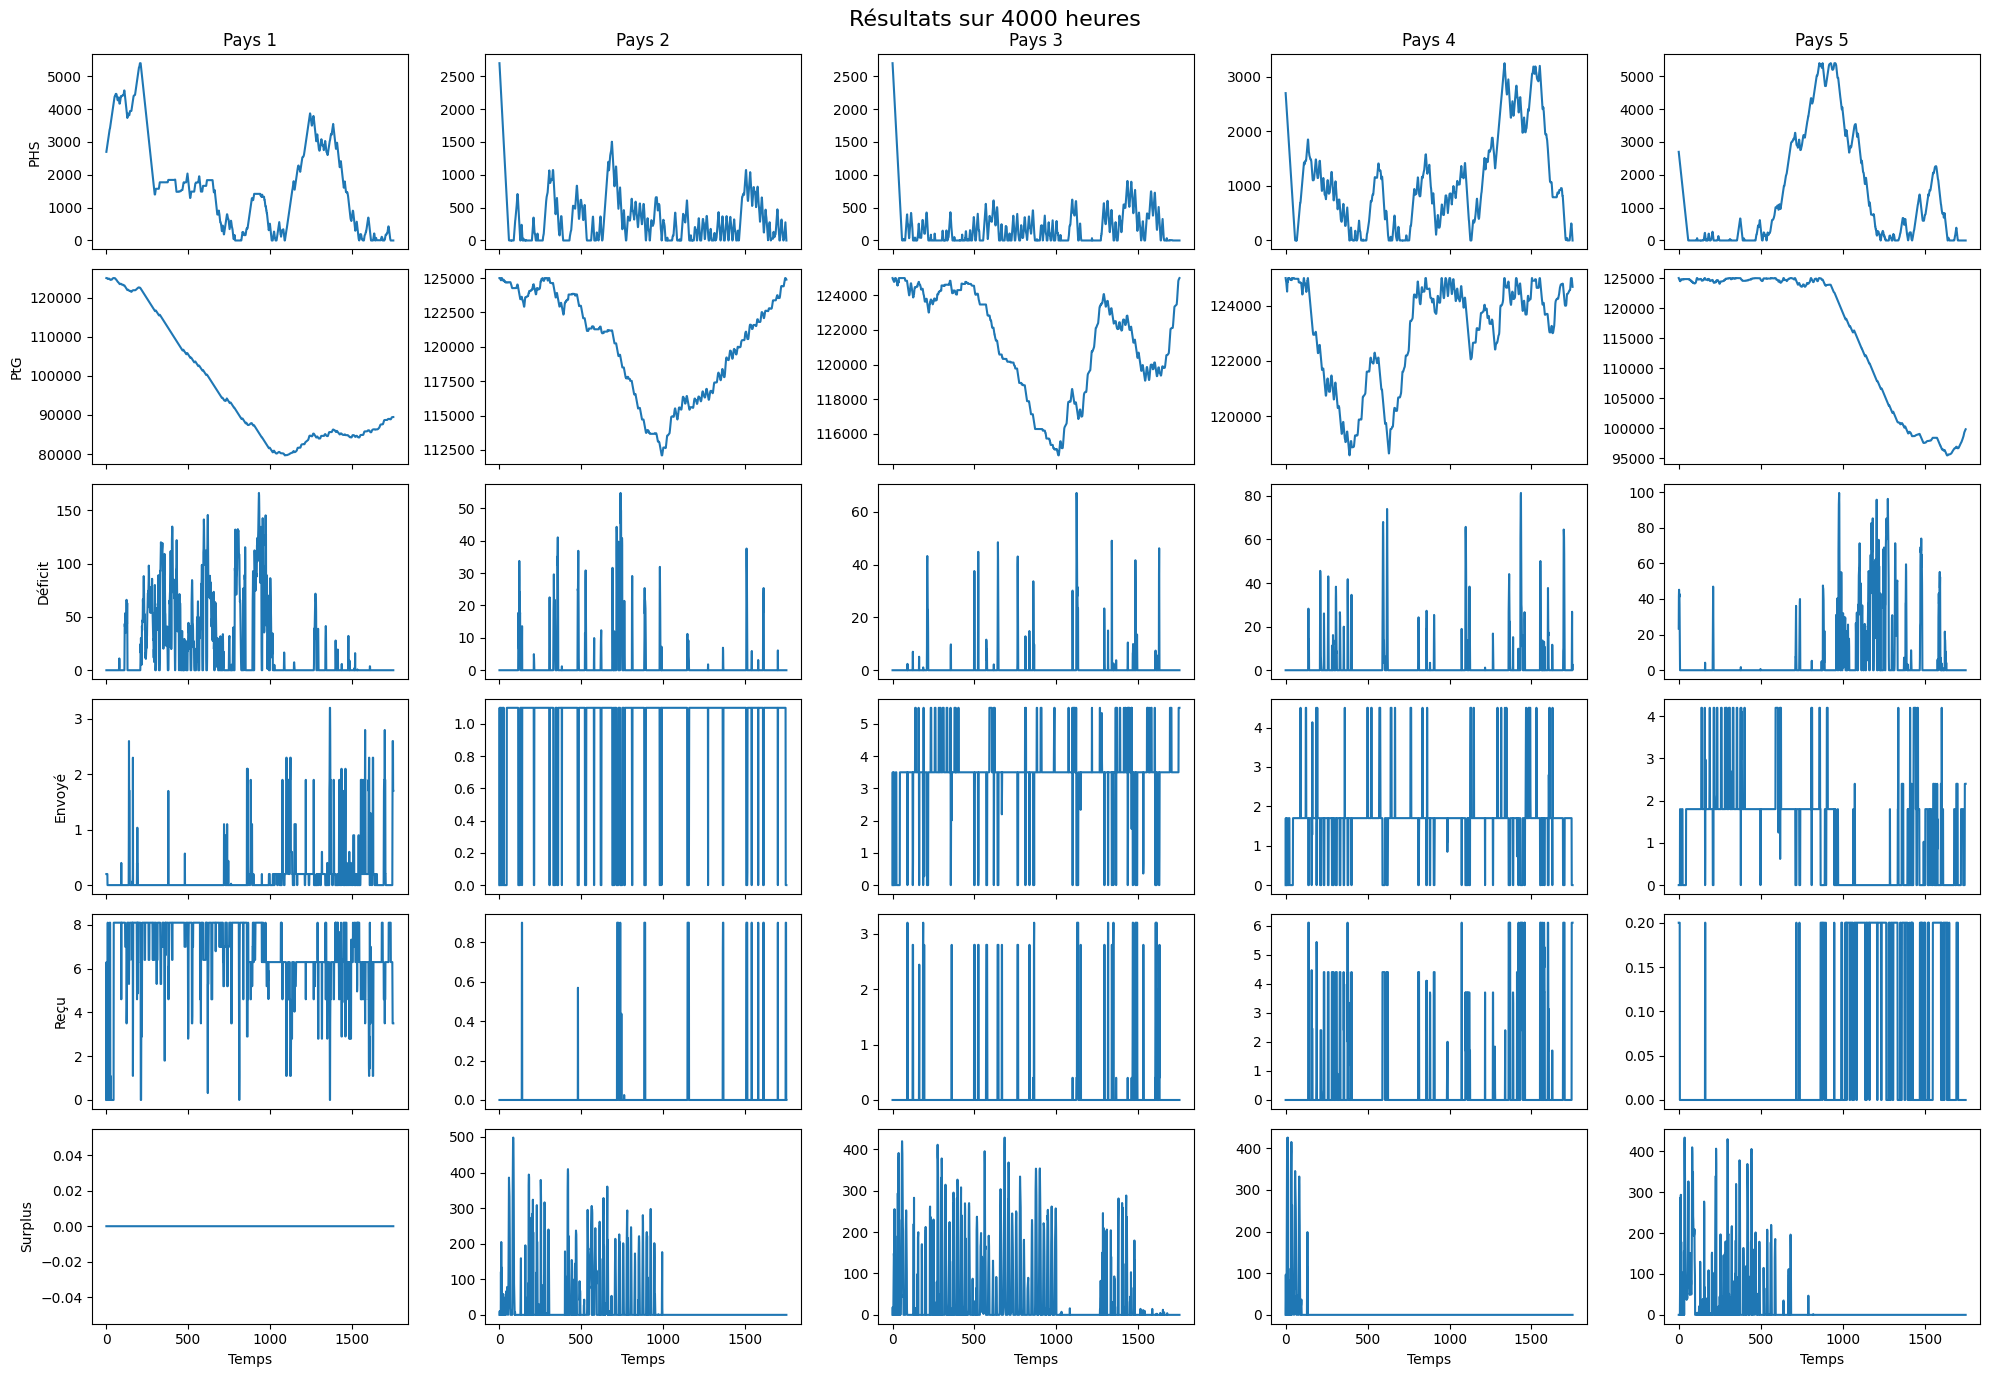

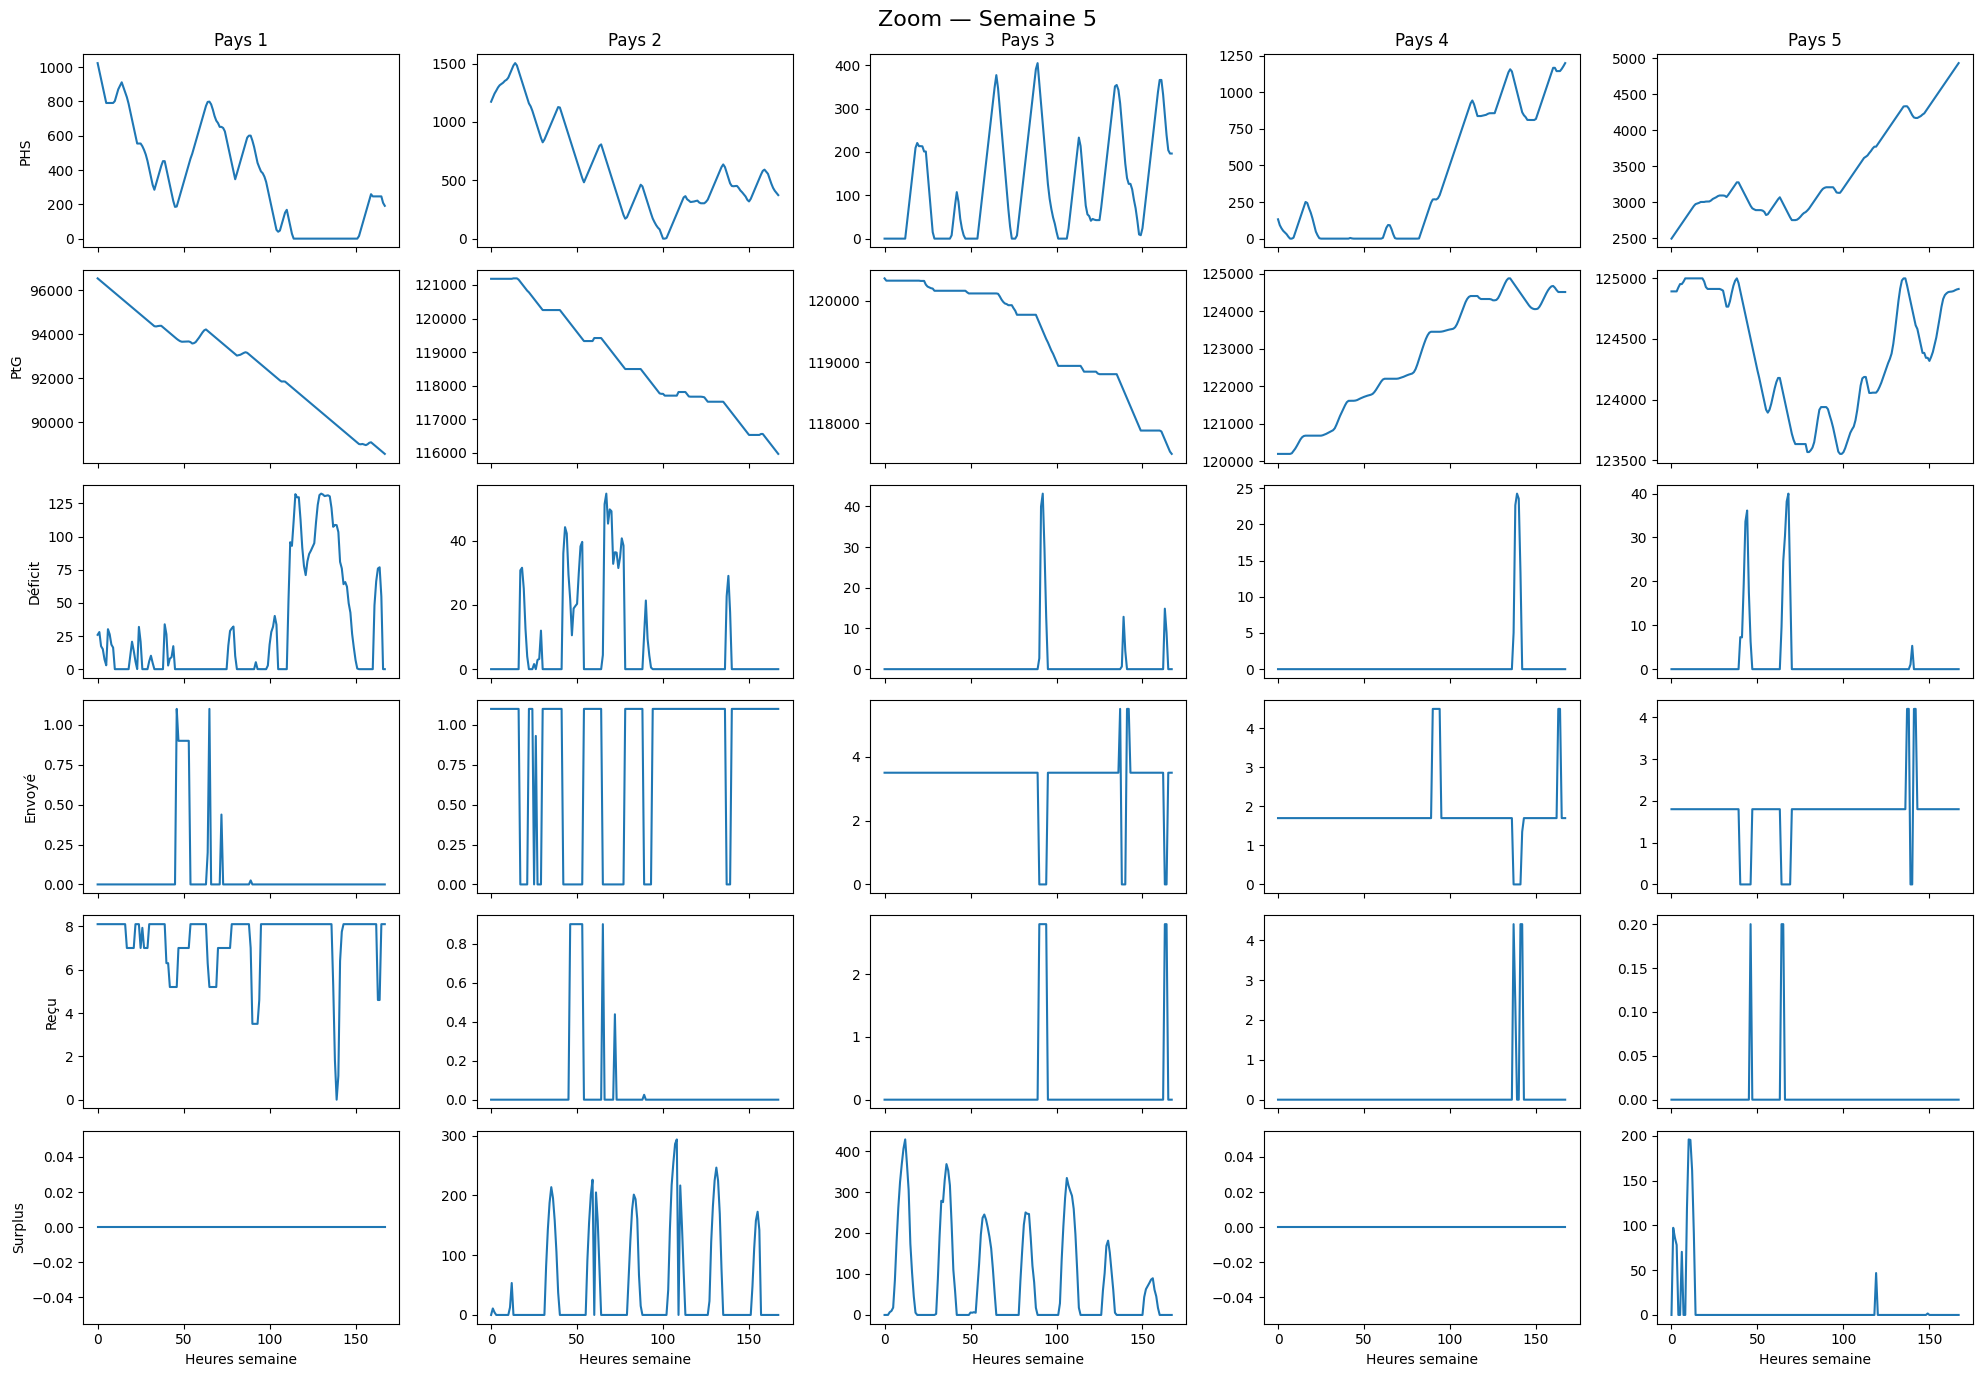

In [6]:
# Affichages
N = result['phs_level'].shape[1]

# --- Flux ---
q = result["Echanges"]  # (T, N, N)
sent = np.sum(q, axis=2)
received = np.sum(q, axis=1)

# =====================================================
# GRAPHE GLOBAL (4000 heures)
# =====================================================
T_plot = 4000

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][:T_plot, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][:T_plot, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][:T_plot, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[:T_plot, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[:T_plot, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")

    axes[5, i].plot(result['surplus'][:T_plot, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Temps")

plt.suptitle("Résultats sur 4000 heures", fontsize=16)
plt.tight_layout()
plt.show()


# =====================================================
# ZOOM SEMAINE
# =====================================================
semaine = 5
T0 = 168 * (semaine - 1)
T1 = T0 + 168

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][T0:T1, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][T0:T1, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][T0:T1, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[T0:T1, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[T0:T1, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")
    
    axes[5, i].plot(result['surplus'][T0:T1, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Heures semaine")

plt.suptitle(f"Zoom — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()


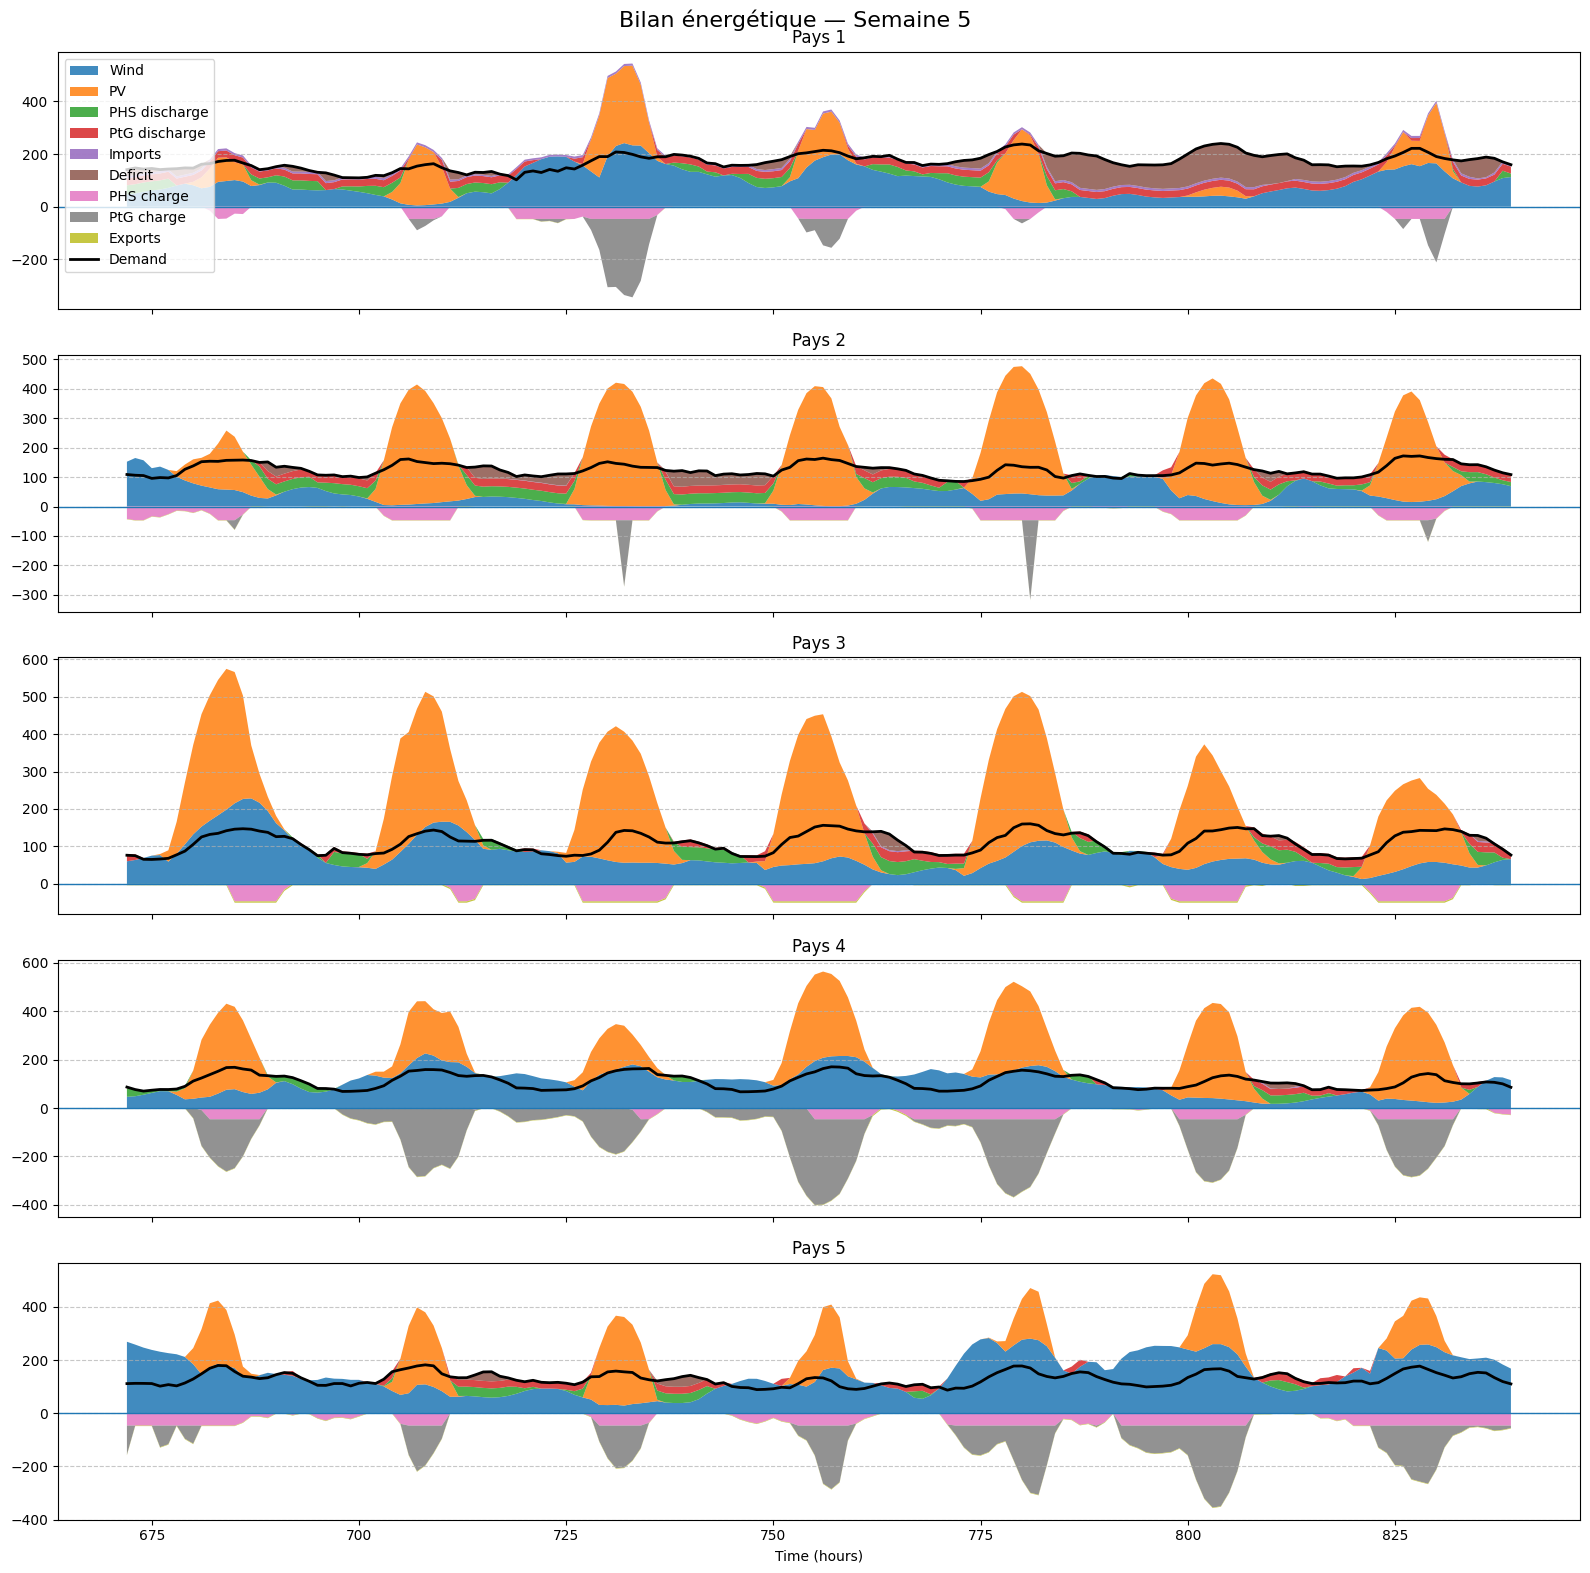

In [7]:
# ===============================
# Flux échanges
# ===============================

ptg_eff=0.4
phs_eff = 0.75
time_axis = np.arange(T0, T1)

q = result["Echanges"]

imports = np.sum(q, axis=1)
exports = np.sum(q, axis=2)

fig, axes = plt.subplots(N, 1, figsize=(16, 16), sharex=True)

for i in range(N):

    # --- Production ---
    wind_i = (wind_N*wind_cap_N)[T0:T1, i]
    solar_i = (solar_N*solar_cap_N)[T0:T1, i]

    # --- Déstockage ---
    phs_dis = phs_eff * result['phs_out'][T0:T1, i]
    ptg_dis = ptg_eff * result['ptg_out'][T0:T1, i]

    # --- Stockage (négatif) ---
    phs_ch = -result['phs_in'][T0:T1, i]
    ptg_ch = -result['ptg_in'][T0:T1, i]

    # --- Echanges ---
    import_i = imports[T0:T1, i]
    export_i = -exports[T0:T1, i]   # NEGATIF

    deficit_i = result['deficit'][T0:T1, i]
    demand_i = demand_N[T0:T1, i]

    # ===== STACK POSITIF =====
    stack_pos = [
        wind_i,
        solar_i,
        phs_dis,
        ptg_dis,
        import_i,
        deficit_i
    ]

    labels_pos = [
        'Wind',
        'PV',
        'PHS discharge',
        'PtG discharge',
        'Imports',
        'Deficit'
    ]

    axes[i].stackplot(time_axis, stack_pos, alpha=0.85)

    # ===== STACK NEGATIF =====
    stack_neg = [
        phs_ch,
        ptg_ch,
        export_i
    ]

    axes[i].stackplot(time_axis, stack_neg, alpha=0.85)

    # --- Demande ---
    axes[i].plot(time_axis,
                 demand_i,
                 color='black',
                 linewidth=2,
                 label='Demand')

    axes[i].axhline(0, linewidth=1)

    axes[i].set_title(f"Pays {i+1}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].legend(labels_pos + ['PHS charge','PtG charge','Exports','Demand'],
                       loc='upper left', fontsize=10)

axes[-1].set_xlabel("Time (hours)")
plt.suptitle(f"Bilan énergétique — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()

## Séparé (1 période)

In [7]:
# Utilisation de la V2

result = sep.optimize2(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=30*180, #modifié en faisant 30*
    phs_power=5*9.3, #modifié en faisant 5*
    phs_eff=0.75,  
    ptg_capacity=125000,
    ptg_power_in=10*7.66, #modifié en faisant 10*
    ptg_power_out=2*32.93,  #modifié en faisant 2*
    ptg_eff=0.4,
    penalisation=1e10,
    flux_eff=0.9
)


#### Commentaires :

-> J'ai enlevé l'assertion demandant des capa max symétriques entre les pays (dans solve_flux issu de la V2) mais il faudra vérifier que le code le traite bien correctement

-> l'idéal serait d'implémenter la V3

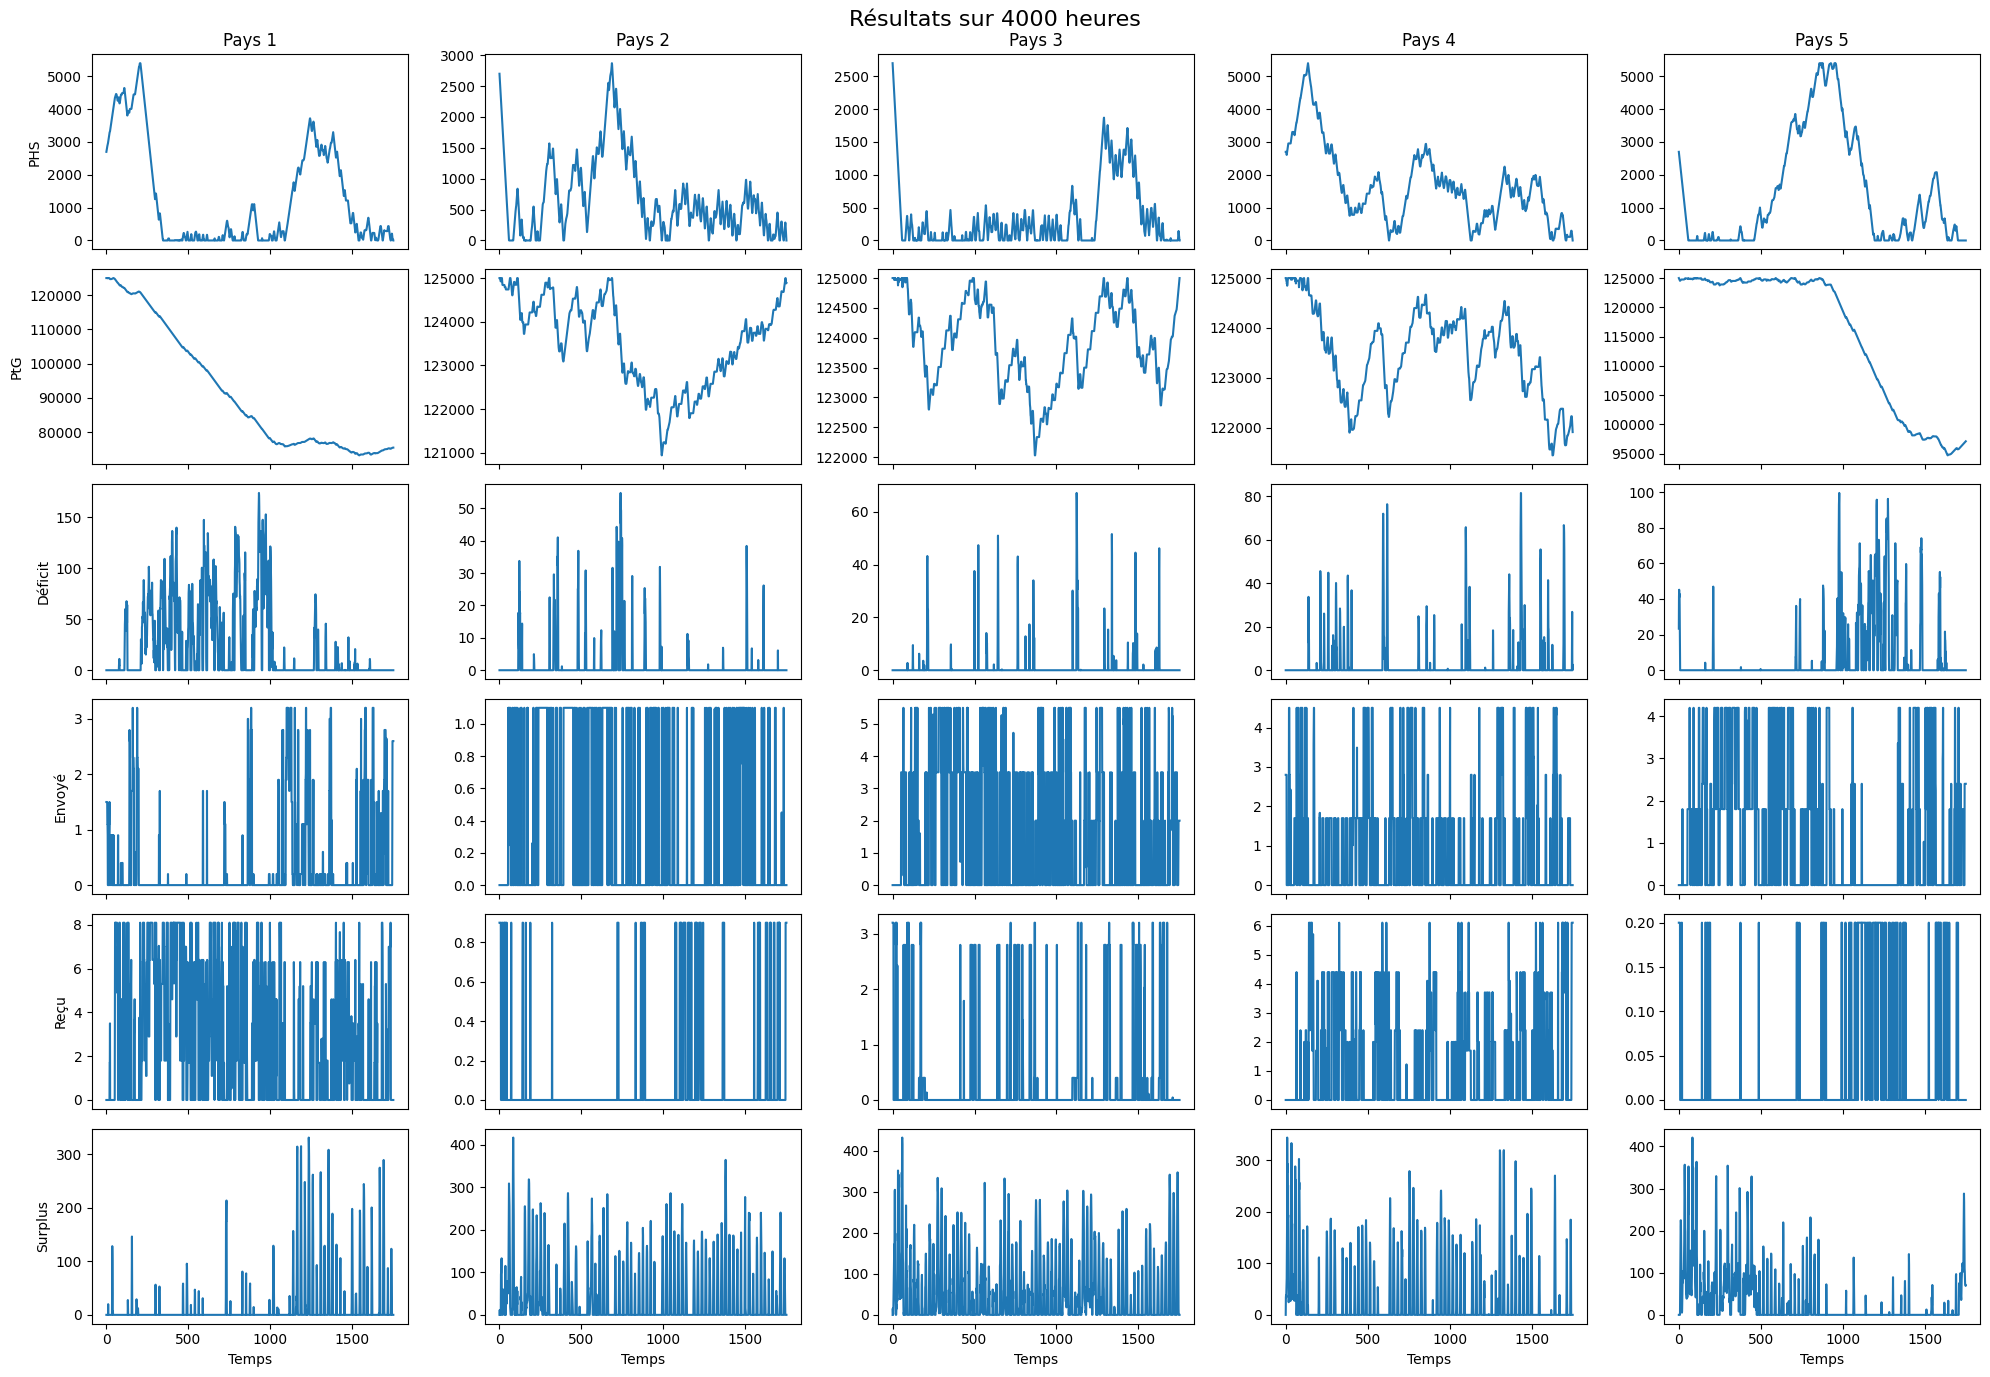

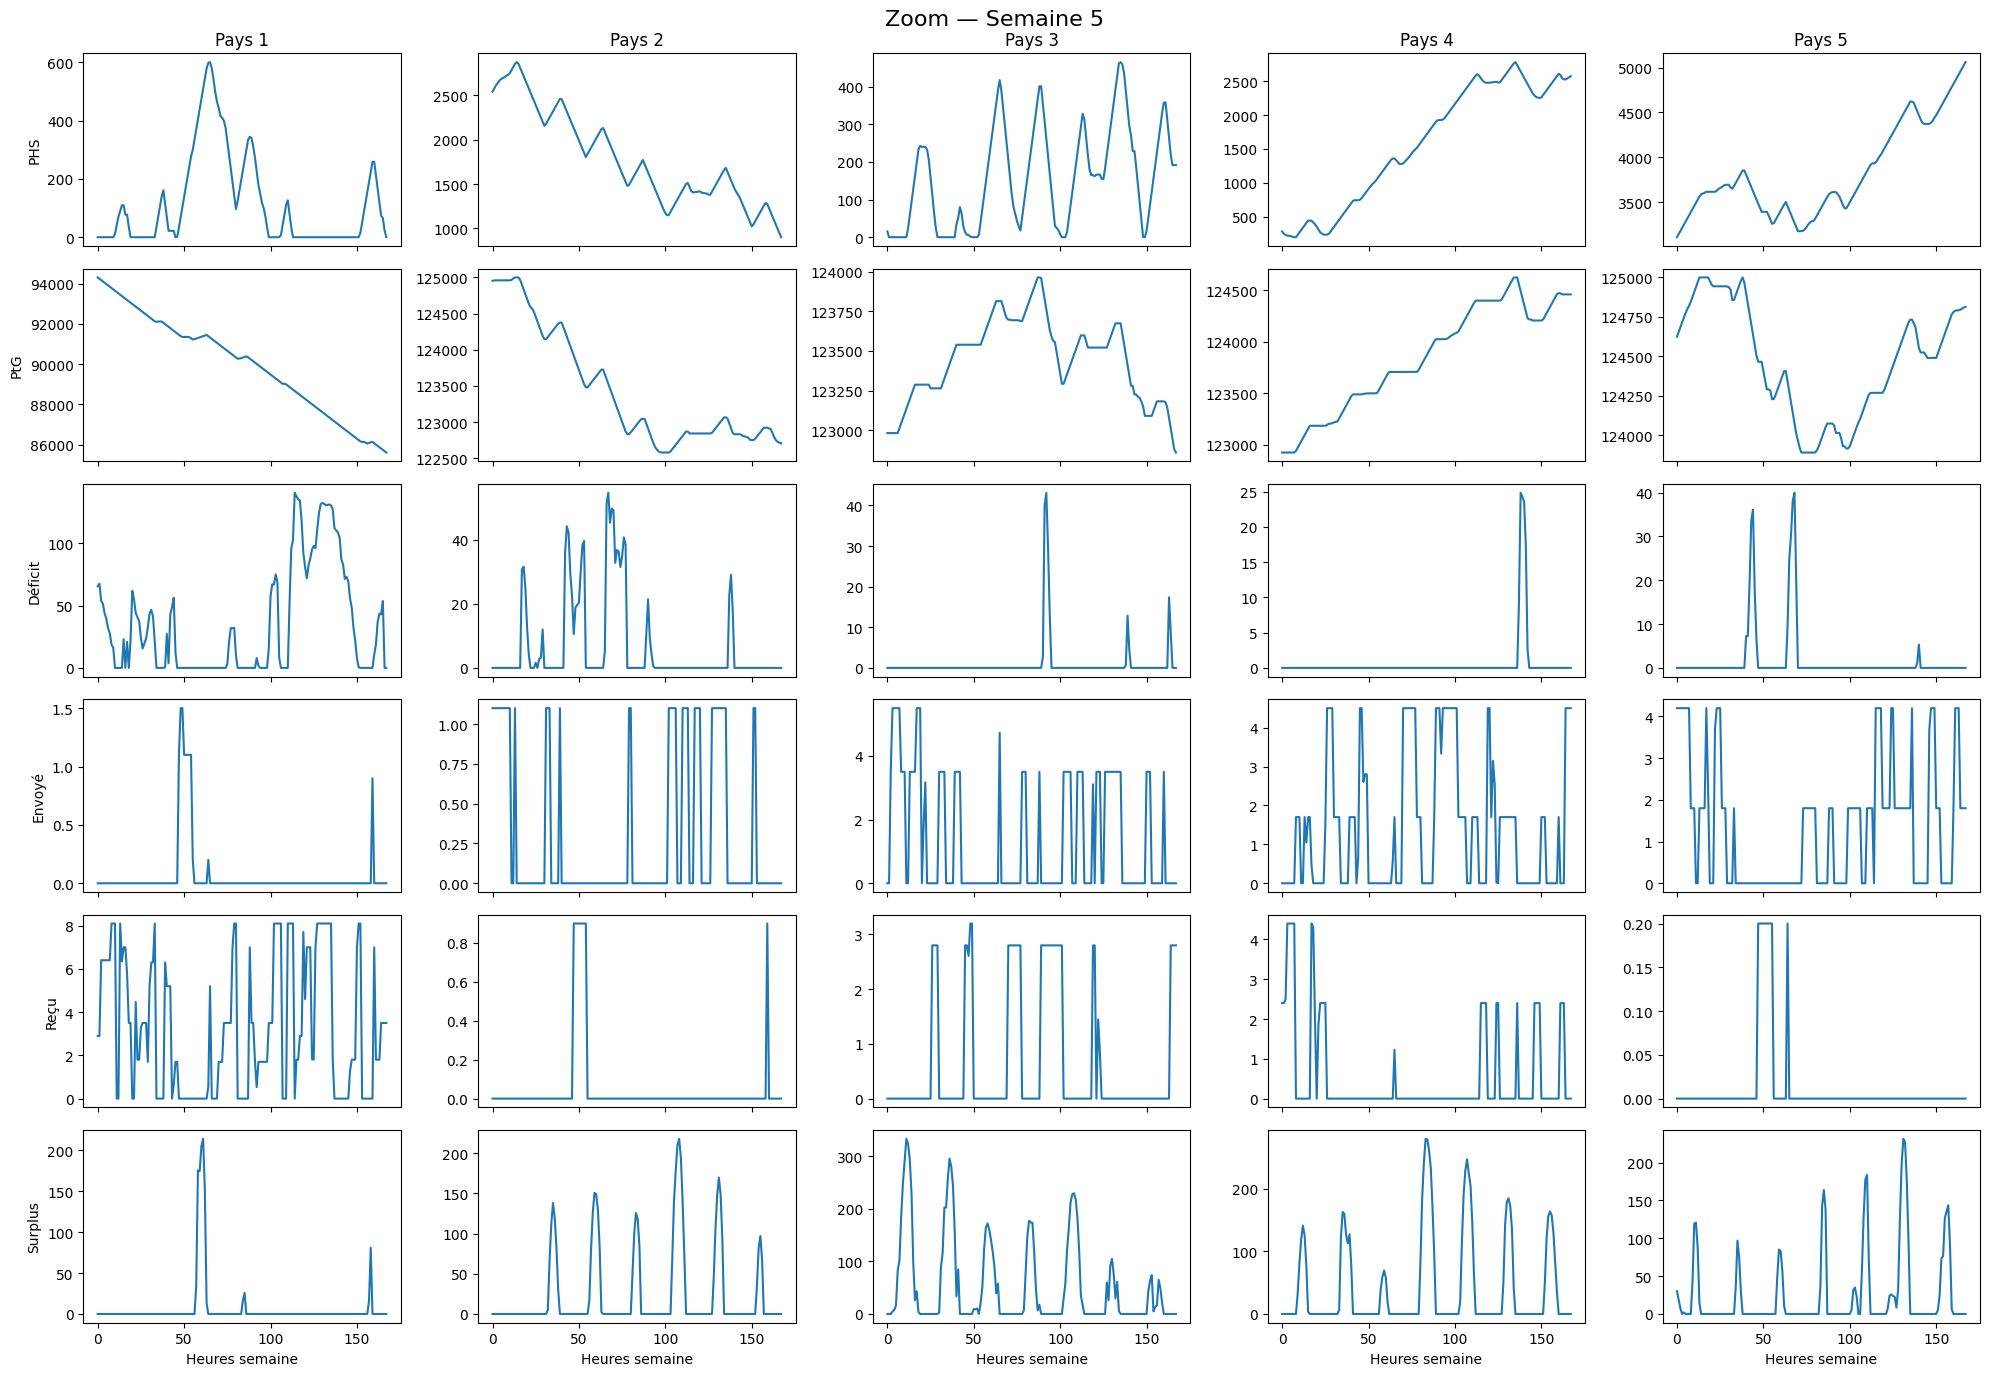

In [8]:
# Affichage graphes
N = result['phs_level'].shape[1]

# --- Flux ---
q = result["Echanges"]  # (T, N, N)
sent = np.sum(q, axis=2)
received = np.sum(q, axis=1)

# =====================================================
# GRAPHE GLOBAL (4000 heures)
# =====================================================
T_plot = 4000

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][:T_plot, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][:T_plot, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][:T_plot, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[:T_plot, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[:T_plot, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")

    axes[5, i].plot(result['surplus'][:T_plot, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Temps")

plt.suptitle("Résultats sur 4000 heures", fontsize=16)
plt.tight_layout()
plt.show()


# =====================================================
# ZOOM SEMAINE
# =====================================================
semaine = 5
T0 = 168 * (semaine - 1)
T1 = T0 + 168

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][T0:T1, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][T0:T1, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][T0:T1, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[T0:T1, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[T0:T1, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")
    
    axes[5, i].plot(result['surplus'][T0:T1, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Heures semaine")

plt.suptitle(f"Zoom — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()


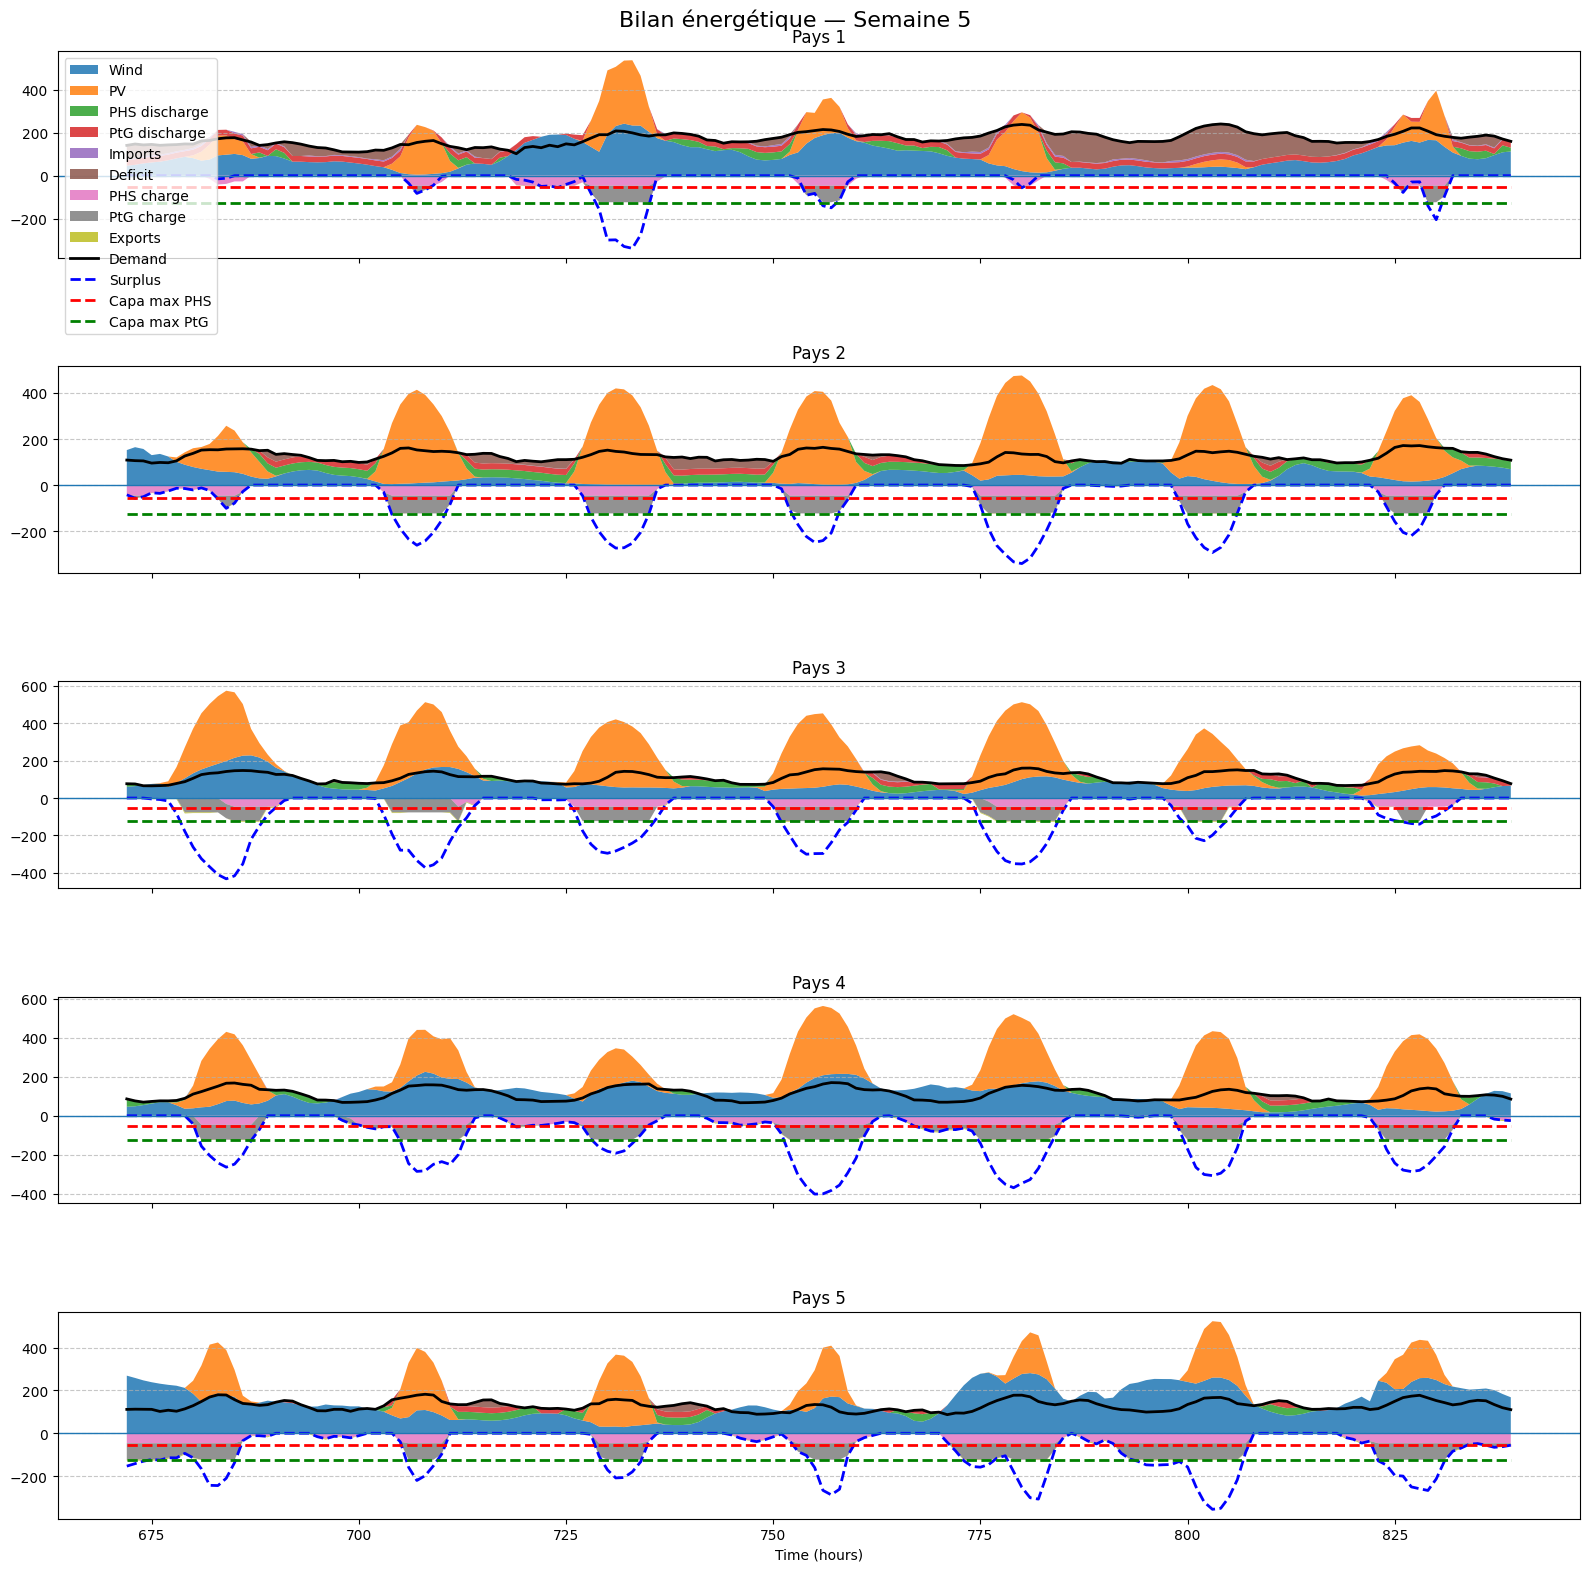

In [ ]:
# Affichage graphes

# ===============================
# Flux échanges
# ===============================

ptg_eff = 0.4
phs_eff = 0.75
time_axis = np.arange(T0, T1)

q = result["Echanges"]

imports = np.sum(q, axis=1)
exports = np.sum(q, axis=2)

fig, axes = plt.subplots(N, 1, figsize=(16, 16), sharex=True)

for i in range(N):

    # --- Production ---
    wind_i = (wind_N*wind_cap_N)[T0:T1, i]
    solar_i = (solar_N*solar_cap_N)[T0:T1, i]

    # --- Déstockage ---
    phs_dis = phs_eff * result['phs_out'][T0:T1, i]
    ptg_dis = ptg_eff * result['ptg_out'][T0:T1, i]

    # --- Stockage (négatif) ---
    phs_ch = -result['phs_in'][T0:T1, i]
    ptg_ch = -result['ptg_in'][T0:T1, i]

    # --- Echanges ---
    import_i = imports[T0:T1, i]
    export_i = -exports[T0:T1, i]   # NEGATIF

    deficit_i = result['deficit'][T0:T1, i]
    demand_i = demand_N[T0:T1, i]

    # --- Surplus avant échange (négatif) ---
    surplus_i = -result["surplus avant echange"][T0:T1, i]

    # --- Capacité max de stockage PHS et PtG ---
    max_storage_phs = np.ones(T1-T0)*3*18
    max_storage_ptg = np.ones(T1-T0)*125


    # ===== STACK POSITIF =====
    stack_pos = [
        wind_i,
        solar_i,
        phs_dis,
        ptg_dis,
        import_i,
        deficit_i
        
    ]

    labels_pos = [
        'Wind',
        'PV',
        'PHS discharge',
        'PtG discharge',
        'Imports',
        'Deficit'
    ]

    axes[i].stackplot(time_axis, stack_pos, alpha=0.85)

    # ===== STACK NEGATIF =====
    stack_neg = [
        phs_ch,
        ptg_ch,
        export_i
    ]

    axes[i].stackplot(time_axis, stack_neg, alpha=0.85)

    # --- Demande ---
    axes[i].plot(time_axis,
                 demand_i,
                 color='black',
                 linewidth=2,
                 label='Demand')
    
    # --- Surplus ---
    axes[i].plot(time_axis,
                 surplus_i,
                 color='blue',
                 linewidth=2,
                 linestyle='--',
                 label='Surplus avant échange')
    
    # --- capacité max stockage phs ---
    axes[i].plot(time_axis,
                 -max_storage_phs,
                 color='red',
                 linewidth=2,
                 linestyle='--',
                 label='Capa max PHS')
    
    # --- capacité max stockage ptg ---
    axes[i].plot(time_axis,
                 -max_storage_ptg,
                 color='green',
                 linewidth=2,
                 linestyle='--',
                 label='Capa max PtG')

    axes[i].axhline(0, linewidth=1)

    axes[i].set_title(f"Pays {i+1}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].legend(labels_pos + ['PHS charge','PtG charge','Exports', 'Demand','Surplus', 'Capa max PHS', 'Capa max PtG'],
                       loc='upper left', fontsize=10)

axes[-1].set_xlabel("Time (hours)")
plt.suptitle(f"Bilan énergétique — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()

## Complet 5 ans

## Séparé 5ans